In [1]:
import os
from pathlib import Path

import ee
import geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import rasterio as rio
import rasterio.sample as rio_sample
import seaborn as sns
import dowhy
import dowhy.datasets
from psmpy import PsmPy

In [2]:
ee.Initialize()

In [3]:
data_path = Path(os.environ["DATA_PATH"])

# Bounds

In [4]:
df_bounds = (
    gpd.read_file(
        data_path / "Areas de intervencion" / "Mancha Urbana" / "MANCHA_URBANA_2018",
    )
    .pipe(lambda df: df.to_crs(df.estimate_utm_crs()))
    .explode()
    .assign(area=lambda df: df["geometry"].area)
    .sort_values("area", ascending=False)
    .head(1)
    .assign(geometry=lambda df: df["geometry"].simplify(10))
    .filter(["geometry"])
    .to_crs("EPSG:4326")
)

bounds_ee = geemap.geopandas_to_ee(df_bounds).first().geometry()

# Temperature

In [5]:
def extract_bits(img: ee.image.Image, from_bit: int, to_bit: int) -> ee.image.Image:
    mask_size = ee.Number(1).add(to_bit).subtract(from_bit)
    mask = ee.Number(1).leftShift(mask_size).subtract(1)
    return img.rightShift(from_bit).bitwiseAnd(mask)


def mask_clouds(img: ee.image.Image) -> ee.image.Image:
    qa = img.select("QA_PIXEL")
    mask = extract_bits(qa, 1, 4).eq(0)
    return img.updateMask(mask)


def get_lst(year: int, temp_band: str, qa_band: str) -> ee.image.Image:
    col = (
        ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
        .filterBounds(bounds_ee)
        .filterDate(f"{year}-12-01", f"{year + 1}-03-01")
        .select([temp_band, qa_band])
    )

    return (
        col.map(mask_clouds)
        .select(temp_band)
        .map(lambda img: img.multiply(0.00341802).add(149 - 273.15))
        .mean()
        .rename(f"b{year}")
    )

In [6]:
test = get_lst(year=2000, temp_band="ST_B6", qa_band="QA_PIXEL")

m = geemap.Map(center=[-19.9207, -43.9378], zoom=12)
m.addLayer(test.select("b2000").clip(bounds_ee))
m

Map(center=[-19.9207, -43.9378], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [7]:
lst = get_lst(year=2000, temp_band="ST_B6", qa_band="QA_PIXEL")

for year in range(2001, 2020):
    lst = lst.addBands(get_lst(year=year, temp_band="ST_B6", qa_band="QA_PIXEL"))

# Greening

In [8]:
img = (
    ee.imagecollection.ImageCollection("users/Caoyue/greening/Green_B")
    .filterBounds(bounds_ee)
    .mosaic()
)

gain_yod = img.select("gain_yod")
loss_yod = img.select("loss_yod")
mix = gain_yod.updateMask(loss_yod.gt(0)).unmask(0)

greening = gain_yod.updateMask(mix.eq(0)).clamp(0, 1).rename("type")
browning = loss_yod.updateMask(mix.eq(0)).clamp(0, 1).multiply(2).rename("type")
green_and_brown = greening.unmask().add(browning.unmask(0)).selfMask()

In [30]:
loss_yod.reduceRegion(ee.reducer.Reducer.min(), bounds_ee, 30).getInfo()

{'loss_yod': 1}

In [32]:
m = geemap.Map(center=[-19.9207, -43.9378], zoom=12)
m.addLayer(gain_yod, {"min": 0, "max": 1, "palette": ["black", "green"]})
m.addLayer(loss_yod, {"min": 0, "max": 1, "palette": ["black", "red"]})
m.addLayer(mix, {"min": 0, "max": 1, "palette": ["black", "blue"]})
m

Map(center=[-19.9207, -43.9378], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

# Samples

## Points

In [9]:
df_samples = (
    ee.data.computeFeatures(
        {
            "expression": ee.image.Image.constant(1)
            .addBands(green_and_brown)
            .stratifiedSample(
                numPoints=100,
                classBand="type",
                region=bounds_ee,
                scale=30,
                geometries=True,
                seed=42,
                classValues=[2],
                classPoints=[500],
            ),
            "fileFormat": "GEOPANDAS_GEODATAFRAME",
        },
    )
    .drop(columns=["constant"])
    .pipe(lambda df: df.set_crs("EPSG:4326"))
    .assign(type=lambda df: df["type"].map({1: 1, 2: 0}))
)

crs = df_samples.estimate_utm_crs()
df_samples = df_samples.to_crs(crs)

col_samples = geemap.geopandas_to_ee(
    df_samples.to_crs("EPSG:4326")[["geometry"]].reset_index(names="index"),
)

## Temperature

In [10]:
start_end_temps = (
    ee.data.computeFeatures(
        {
            "expression": lst.select(["b2000", "b2019"]).sampleRegions(
                col_samples, scale=30,
            ),
            "fileFormat": "GEOPANDAS_GEODATAFRAME",
        },
    )
    .set_index("index")
    .drop(columns=["geometry"])
    .rename(columns={"b2000": "start_temp", "b2019": "end_temp"})
)

df_samples = df_samples.drop(columns=["start_temp", "end_temp"], errors="ignore").join(
    start_end_temps,
)

Text(0.5, 0, 'Temperature Change (°C)')

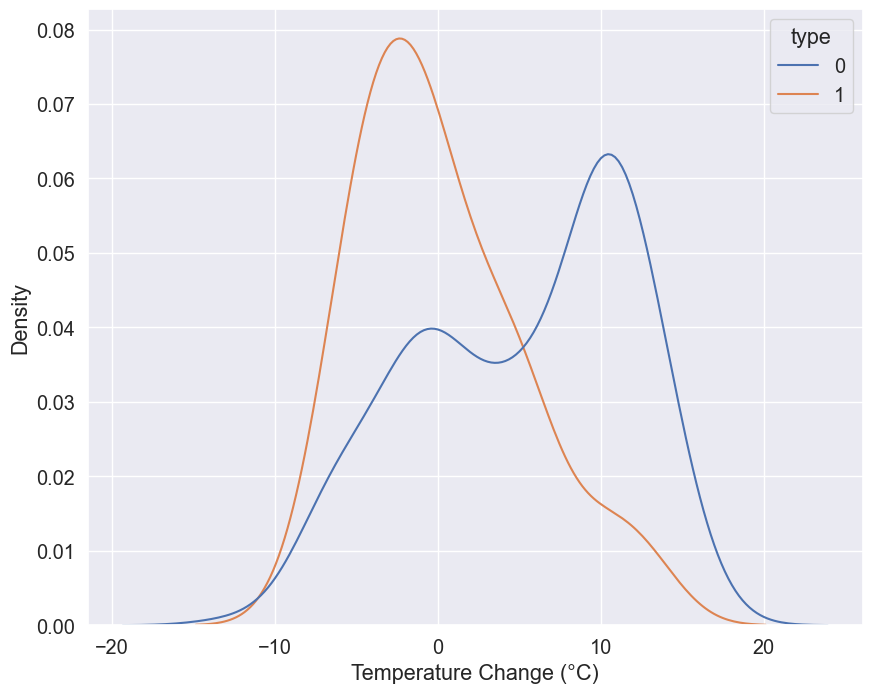

In [11]:
sns.kdeplot(df_samples.assign(diff=lambda df: df["end_temp"] - df["start_temp"]), x="diff", hue="type", common_norm=False)
plt.xlabel("Temperature Change (°C)")

## Elevation

In [12]:
df_level = (
    gpd.read_file(
        data_path / "Areas de intervencion" / "Altimetria_MDT" / "CURVA_DE_NIVEL_5M",
    )
    .pipe(lambda df: df.to_crs(crs))
    .filter(["COTA", "geometry"])
    .rename(columns={"COTA": "elevation"})
)

joined = (
    df_samples[["geometry"]]
    .sjoin_nearest(df_level)
    .reset_index(names="index")
    .drop_duplicates(subset="index")
    .set_index("index")
    ["elevation"]
)

df_samples = df_samples.assign(elevation=joined)

## Slope

In [13]:
with rio.open(data_path / "Ide_bhgeo_mosaico-declividade_curva_nivel_2015.tif") as ds:
    coords = [(geom.x, geom.y) for geom in df_samples.geometry]
    slope_values = list(rio_sample.sample_gen(ds, coords))
    df_samples = df_samples.assign(slope=[val[0] for val in slope_values])

## Lights

In [14]:
img_lights = (
    ee.imagecollection.ImageCollection("projects/sat-io/open-datasets/srunet-npp-viirs-ntl")
    .filterBounds(bounds_ee)
    .filter(ee.filter.Filter.eq("id_no", "SRUNet_NPP_VIIRS_V2_Like_2020"))
    .first()
)

df_lights = ee.data.computeFeatures({
    "expression": img_lights.sampleRegions(col_samples, scale=500),
    "fileFormat": "GEOPANDAS_GEODATAFRAME",
}).set_index("index").drop(columns=["geometry"])

df_samples = df_samples.assign(lights=df_lights)

## Land use

In [19]:
img_landuse = (
    ee.imagecollection.ImageCollection("projects/sat-io/open-datasets/GLC-FCS30D/annual")
    .filterBounds(bounds_ee)
    .select("b20")
    .mode()
)

df_landuse = ee.data.computeFeatures({
    "expression": img_landuse.sampleRegions(col_samples, scale=30),
    "fileFormat": "GEOPANDAS_GEODATAFRAME",
}).set_index("index").drop(columns=["geometry"]).rename(columns={"b20": "landuse"})["landuse"]

df_samples = df_samples.assign(landuse=df_landuse)

In [24]:
df_samples.groupby(["type", "landuse"]).size().unstack().fillna(0).pipe(lambda df: df.divide(df.sum(axis=1), axis=0))

landuse,11,51,52,62,71,91,120,190,210
type,,,,,,,,,
0,0.006,0.002,0.002,0.01,0.00,0.002,0.006,0.968,0.004
1,0.030,0.000,0.060,0.11,0.01,0.010,0.140,0.630,0.010


<Axes: xlabel='landuse', ylabel='type'>

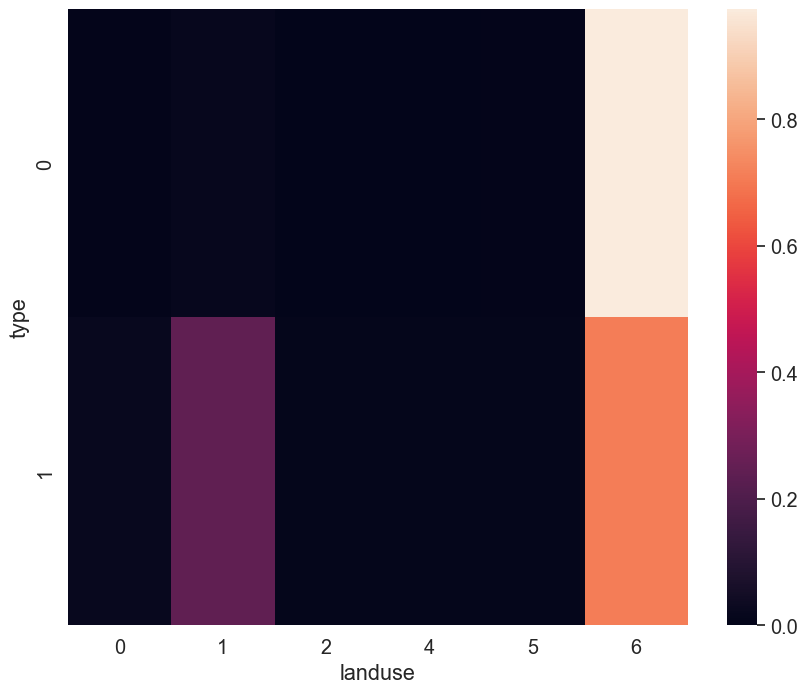

In [29]:
sns.heatmap(df_samples.groupby(["type", "landuse"]).size().unstack().fillna(0).pipe(lambda df: df.divide(df.sum(axis=1), axis=0)))

## Save

In [168]:
df_samples.drop(columns=["geometry"]).to_csv("./df.csv", index=False)
df_samples.to_file("./df_samples.gpkg", driver="GPKG")

## Matching

In [169]:
not_matched = (
    df_samples.reset_index(names="index")
    .drop(columns=["geometry"])
    # .dropna(subset=["start_temp"])
)

psm = PsmPy(
    not_matched,
    treatment="type",
    indx="index",
    exclude=["end_temp", "start_temp"],
    seed=42,
)
psm.logistic_ps(balance=True)
psm.kdtree_matched(
    matcher="propensity_logit", replacement=False, caliper=0.05, drop_unmatched=True,
)

<Axes: xlabel='propensity_logit', ylabel='Density'>

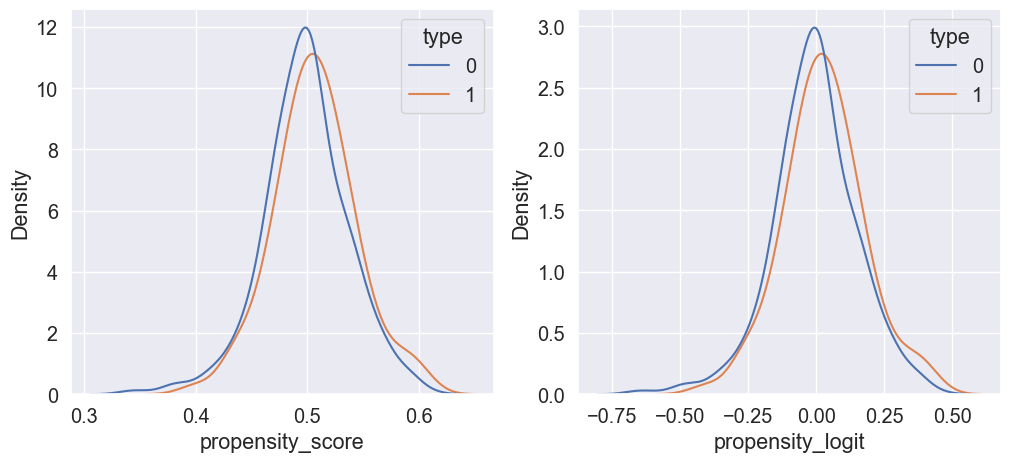

In [170]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(psm.predicted_data, hue="type", x="propensity_score", ax=axl, common_norm=False)
sns.kdeplot(psm.predicted_data, hue="type", x="propensity_logit", ax=axr, common_norm=False)

In [171]:
matched_treatment = df_samples.loc[psm.matched_ids["matched_ID"]]
matched_control = df_samples.loc[psm.matched_ids["index"]]
matched = pd.concat([matched_treatment, matched_control])

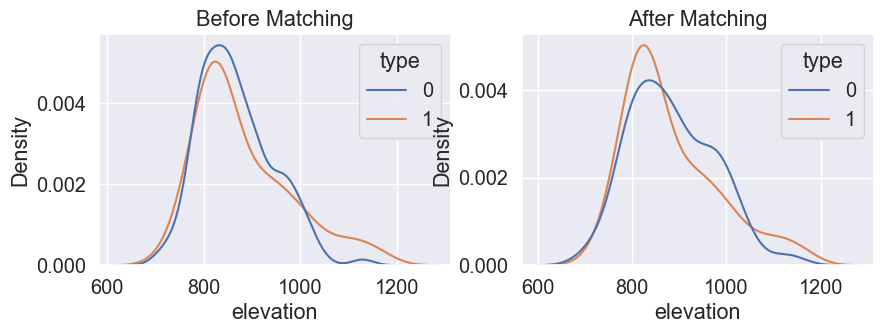

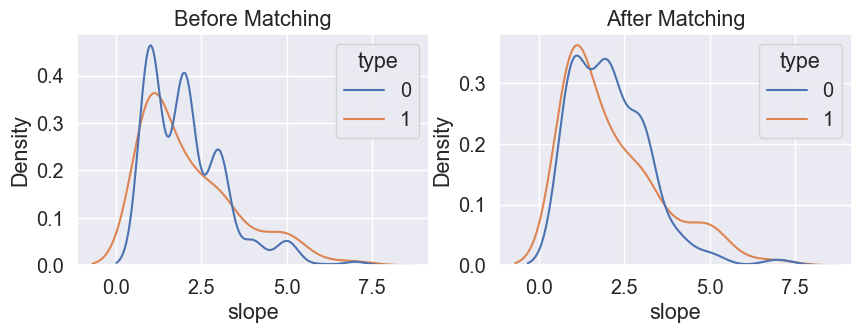

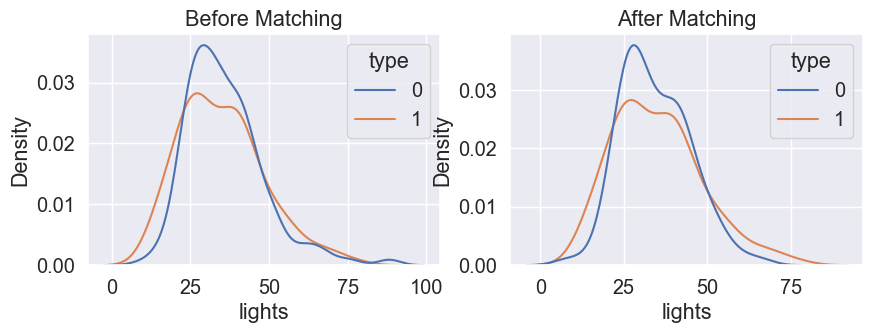

In [172]:
for var in df_samples.columns.drop(["type", "geometry", "start_temp", "end_temp"]):
    fig, (axl, axr) = plt.subplots(1, 2, figsize=(10, 3))
    sns.kdeplot(data=not_matched, x=var, hue="type", ax=axl, common_norm=False)
    sns.kdeplot(data=matched, x=var, hue="type", ax=axr, common_norm=False)
    axl.set_title("Before Matching")
    axr.set_title("After Matching")

In [158]:
df_samples

,geometry,type,start_temp,end_temp,elevation,slope,lights
0,POINT (605990.015 7801694.569),1,NaN,NaN,830.0,1,27.636007
1,POINT (604588.447 7808026.116),1,NaN,NaN,800.0,2,22.362154
2,POINT (608876.565 7812235.619),1,27.991197,22.930819,810.0,3,14.608675
3,POINT (610467.511 7804769.094),1,NaN,NaN,780.0,3,25.396776
4,POINT (602688.504 7796822.58),1,NaN,NaN,960.0,1,17.412914
...,...,...,...,...,...,...,...
695,POINT (603278.762 7796461.208),0,NaN,NaN,930.0,1,33.823910
696,POINT (605091.016 7807098.523),0,NaN,NaN,810.0,1,27.233400
697,POINT (605077.252 7790604.522),0,27.876694,36.667841,980.0,4,26.929394
698,POINT (603963.483 7797769.541),0,NaN,NaN,865.0,3,18.568787


<Axes: xlabel='diff'>

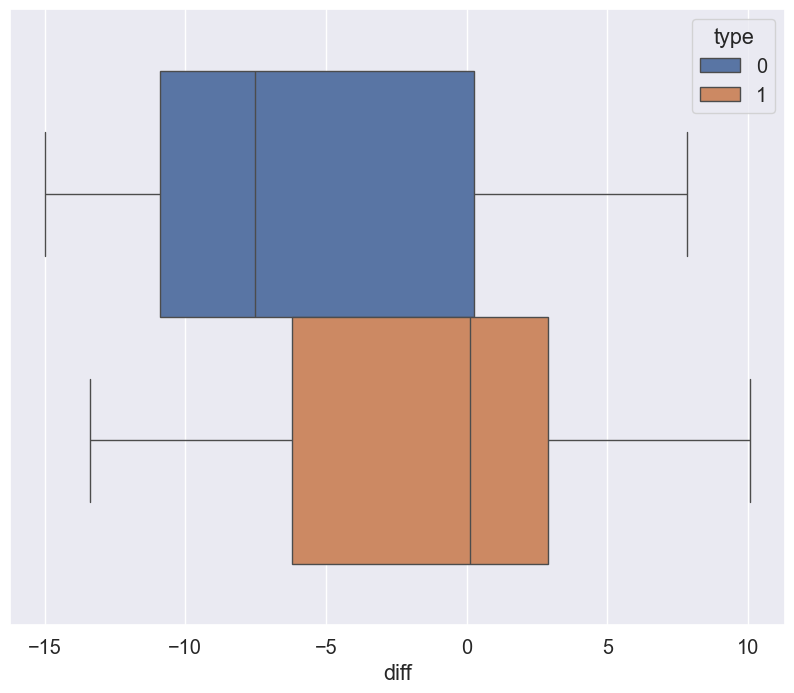

In [157]:
test = matched.assign(diff=lambda df: df["start_temp"] - df["end_temp"])
sns.boxplot(test, x="diff", hue="type")